In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

Selected 12 Features:

- UGC_GOAL_WALK_count
- UGC_ICE_BLOCK_1_count
- UGC_BUBBLE_POPPABLE_count
- UGC_PLATFORM_BUBBLE_count
- UGC_ONE_WAY_PLATFORM_count
- UGC_SLIMY_count
- UGC_CHAIN_count
- UGC_BALLOON_count
- UGC_CHARACTER_LEMMING_count
- UGC_CHARACTER_LEMMING_1_value
- UGC_EDITABLE_RECTANGLE_ICE_1_value
- UGC_EDITABLE_RECTANGLE_LAVA_1_value

**Play-created Levels**

A total of 144 levels.

In [ ]:
file_name = '/content/Player_Only.xls'

selected_features = [
    'UGC_BUBBLE_POPPABLE_count',
    'UGC_PLATFORM_BUBBLE_count',
    'UGC_CHAIN_count',
    'UGC_ONE_WAY_PLATFORM_count',
    'UGC_CHARACTER_LEMMING_count',
    'UGC_BALLOON_count',
    'UGC_CHARACTER_LEMMING_1_value',
    'UGC_EDITABLE_RECTANGLE_ICE_1_value',
    'UGC_EDITABLE_RECTANGLE_LAVA_1_value',
    'UGC_GOAL_WALK_count',
    'UGC_SLIMY_count',
    'UGC_ICE_BLOCK_1_count'
]
target_variable = 'Selected'
df = pd.read_excel(file_name, usecols=selected_features + [target_variable])
df = df.dropna().reset_index(drop=True)

In [ ]:
stats_df = df.groupby(target_variable)[selected_features].agg(['mean', 'std']).T
stats_df.columns = ['Discarded (0)', 'Selected (1)']
stats_df.index.names = ['Feature', 'Statistic']
stats_df = stats_df.map(lambda x: f"{x:.2f}")

print("\n" + "="*70)
print("FEATURES MEAN & SD BY SELECTED STATUS")
print("="*70)
print(stats_df.to_string())


FEATURES MEAN & SD BY SELECTED STATUS
                                              Discarded (0) Selected (1)
Feature                             Statistic                           
UGC_BUBBLE_POPPABLE_count           mean               1.70         4.00
                                    std                4.03         8.26
UGC_PLATFORM_BUBBLE_count           mean               1.43         2.07
                                    std                3.03         4.26
UGC_CHAIN_count                     mean               2.95         2.75
                                    std                6.16         4.10
UGC_ONE_WAY_PLATFORM_count          mean               0.58         3.74
                                    std                1.19         4.31
UGC_CHARACTER_LEMMING_count         mean               2.25         1.31
                                    std                3.82         3.33
UGC_BALLOON_count                   mean               6.43         3.96
            

In [ ]:
desc_table = df.describe()
print(desc_table)

         Selected  UGC_GOAL_WALK_count  UGC_ICE_BLOCK_1_count  \
count  144.000000           144.000000             144.000000   
mean     0.472222             1.034722               0.701389   
std      0.500970             1.511787               2.826151   
min      0.000000             0.000000               0.000000   
25%      0.000000             1.000000               0.000000   
50%      0.000000             1.000000               0.000000   
75%      1.000000             1.000000               0.000000   
max      1.000000            17.000000              27.000000   

       UGC_BUBBLE_POPPABLE_count  UGC_PLATFORM_BUBBLE_count  \
count                 144.000000                 144.000000   
mean                    2.784722                   1.736111   
std                     6.467956                   3.662293   
min                     0.000000                   0.000000   
25%                     0.000000                   0.000000   
50%                     0.000000    

**Player-created levels + Expert-created levels**

A total of 249 levels.

Player_creates

1: 144

0: 105

Selected

1: 173

0:76

In [ ]:
file_name = '/content/Final_Combined_Dataset.xlsx'

# 我们之前精选出的 12 个 Features
selected_features = [
    'UGC_BUBBLE_POPPABLE_count',
    'UGC_PLATFORM_BUBBLE_count',
    'UGC_CHAIN_count',
    'UGC_ONE_WAY_PLATFORM_count',
    'UGC_CHARACTER_LEMMING_count',
    'UGC_BALLOON_count',
    'UGC_CHARACTER_LEMMING_1_value',
    'UGC_EDITABLE_RECTANGLE_ICE_1_value',
    'UGC_EDITABLE_RECTANGLE_LAVA_1_value',
    'UGC_GOAL_WALK_count',
    'UGC_SLIMY_count',
    'UGC_ICE_BLOCK_1_count',
    'Player_created'
]

target_variable = 'Selected'
columns_to_load = selected_features + [target_variable]

df = pd.read_excel(file_name, usecols=columns_to_load)
df = df.dropna()

X = df[selected_features]
y = df[target_variable]

**Cross-validation**

Executing Nested CV (25 outer splits) ...
------------------------------------------------------------
🔄 Analyzing model: KNN ...
  >> Avg Inner Acc: 0.8298
  >> Avg Outer Acc: 0.7983
  >> Most common best params: {'clf__n_neighbors': 9, 'clf__p': 1}
----------------------------------------
🔄 Analyzing model: DT ...
  >> Avg Inner Acc: 0.8332
  >> Avg Outer Acc: 0.8174
  >> Most common best params: {'criterion': 'gini', 'max_depth': 2}
----------------------------------------
🔄 Analyzing model: SVM ...
  >> Avg Inner Acc: 0.8374
  >> Avg Outer Acc: 0.8228
  >> Most common best params: {'clf__C': np.float64(10.0), 'clf__gamma': np.float64(0.001), 'clf__kernel': 'rbf'}
----------------------------------------
🔄 Analyzing model: RF ...
  >> Avg Inner Acc: 0.8366
  >> Avg Outer Acc: 0.8265
  >> Most common best params: {'n_estimators': 200}
----------------------------------------

=== Nested CV Performance Summary ===
Model Inner_Acc Outer_Acc                                              

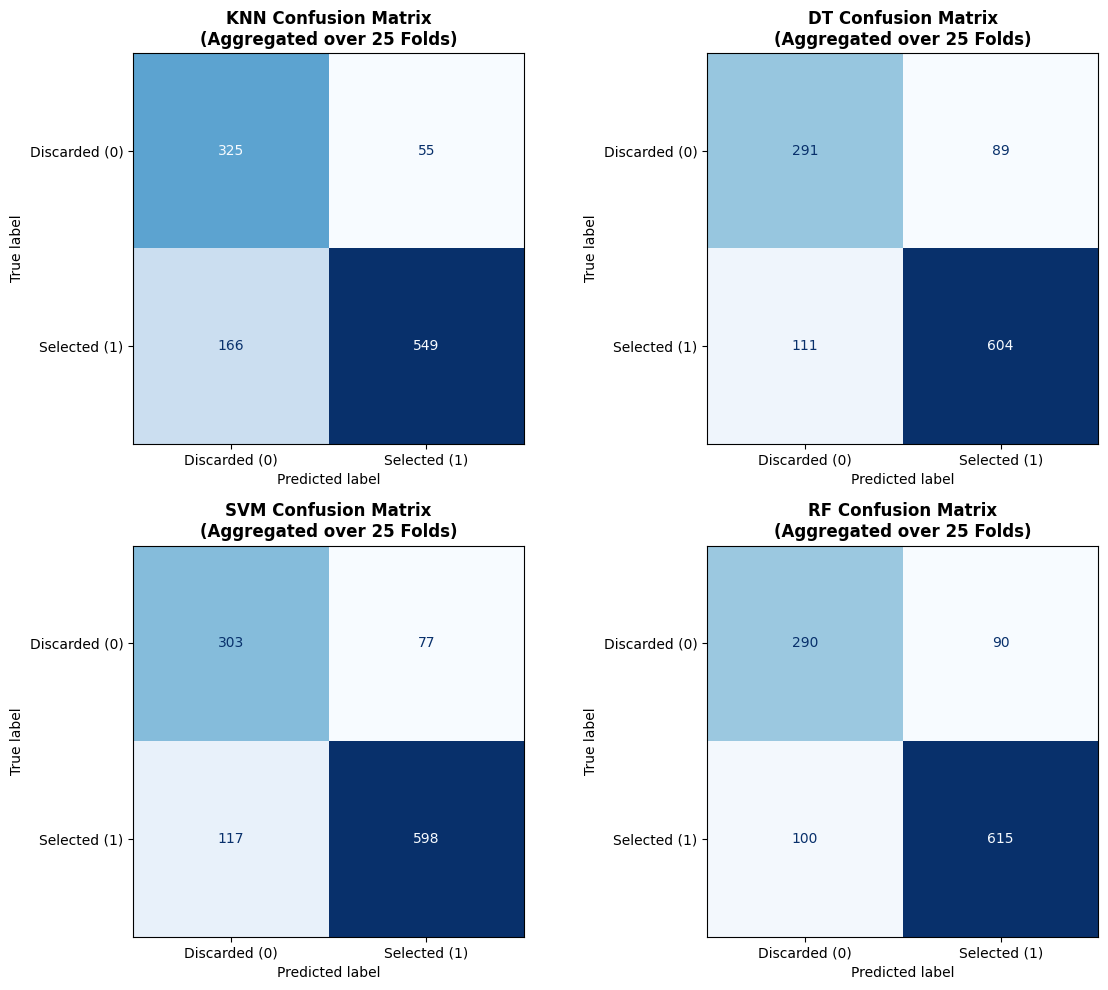

In [ ]:
C_range = np.logspace(-2, 2, 5)
gamma_range = np.logspace(-3, -1, 3)

models_config = {
    'KNN': {
        'model': Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())]),
        'params': {'clf__n_neighbors': list(range(1, 10)), 'clf__p': [1, 2]}
    },
    'DT': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': list(range(1, 10)) + [None], 'criterion': ['gini', 'entropy']}
    },
    'SVM': {
        'model': Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=False, random_state=42))]),
        'params': [
            {'clf__kernel': ['rbf'], 'clf__C': C_range, 'clf__gamma': gamma_range},
            {'clf__kernel': ['linear'], 'clf__C': C_range}
        ]
    },
    'RF': {
        'model': RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [10, 50, 100, 200]}
    }
}

# ==========================================
# Nested Cross-Validation Execution
# ==========================================
outer_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
inner_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

results_log = []
confusion_data = {}

print("Executing Nested CV (25 outer splits) ...")
print("-" * 60)

for name, config in models_config.items():
    print(f"🔄 Analyzing model: {name} ...")

    all_y_true, all_y_pred = [], []
    inner_scores, outer_scores, best_params_history = [], [], []

    # Outer loop
    for train_ix, test_ix in outer_cv.split(X, y):
        X_train, X_test = X.iloc[train_ix], X.iloc[test_ix]
        y_train, y_test = y.iloc[train_ix], y.iloc[test_ix]

        # Inner loop: Hyperparameter tuning
        clf = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            cv=inner_cv,
            scoring='accuracy',
            n_jobs=-1
        )
        clf.fit(X_train, y_train)

        # Record inner results
        inner_scores.append(clf.best_score_)
        best_params_history.append(str(clf.best_params_))

        # Outer loop evaluation
        y_pred = clf.predict(X_test)
        outer_scores.append(accuracy_score(y_test, y_pred))

        # Collect data for confusion matrix
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

    confusion_data[name] = (all_y_true, all_y_pred)

    avg_inner = np.mean(inner_scores)
    avg_outer = np.mean(outer_scores)

    # Find the most common best parameter set
    from collections import Counter
    most_common_param = Counter(best_params_history).most_common(1)[0][0]

    print(f"  >> Avg Inner Acc: {avg_inner:.4f}")
    print(f"  >> Avg Outer Acc: {avg_outer:.4f}")
    print(f"  >> Most common best params: {most_common_param}")
    print("-" * 40)

    results_log.append({
        'Model': name,
        'Inner_Acc': f"{avg_inner:.4f}",
        'Outer_Acc': f"{avg_outer:.4f}",
        'Best_Params_Mode': most_common_param
    })

# ==========================================
# Print Summary & Plot Confusion Matrices
# ==========================================
results_df = pd.DataFrame(results_log)
print("\n=== Nested CV Performance Summary ===")
print(results_df.to_string(index=False))

# Plot Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

labels_display = ['Discarded (0)', 'Selected (1)']

for i, (name, (y_true, y_pred)) in enumerate(confusion_data.items()):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_display)
    disp.plot(ax=axes[i], cmap='Blues', values_format='d', colorbar=False)

    axes[i].set_title(f'{name} Confusion Matrix\n(Aggregated over 25 Folds)', fontsize=12, fontweight='bold')
    axes[i].grid(False)

plt.tight_layout()
plt.show()

With best params

In [ ]:
models = {
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=9, p=1))
    ]),

    'DT': DecisionTreeClassifier(
        criterion='gini',
        max_depth=2,
        random_state=42
    ),

    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=10.0, gamma=0.001, probability=True, random_state=42))
    ]),

    'RF': RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

In [ ]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
scoring_metrics = ['accuracy', 'roc_auc', 'f1_macro']

final_results = []

for name, model in models.items():
    print(f"   ⏳ Evaluating {name} ...")
    # Execute cross-validation with multiple scoring metrics
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring_metrics, n_jobs=-1)

    # Calculate mean and standard deviation for each metric
    final_results.append({
        'Model': name,
        'Accuracy': f"{cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}",
        'ROC_AUC': f"{cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}",
        'F1_Score': f"{cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}"
    })

# ==========================================
# 4. Print Final Performance Comparison Table
# ==========================================
results_df = pd.DataFrame(final_results)
print("\n" + "="*60)
print("FINAL MODELS PERFORMANCE (with Best Hyperparameters)")
print("="*60)
print(results_df.to_string(index=False))

   ⏳ Evaluating KNN ...
   ⏳ Evaluating DT ...
   ⏳ Evaluating SVM ...
   ⏳ Evaluating RF ...

FINAL MODELS PERFORMANCE (with Best Hyperparameters)
Model        Accuracy         ROC_AUC        F1_Score
  KNN 0.8229 ± 0.0505 0.9027 ± 0.0455 0.8172 ± 0.0506
   DT 0.8201 ± 0.0467 0.8796 ± 0.0402 0.7998 ± 0.0506
  SVM 0.8311 ± 0.0546 0.9048 ± 0.0414 0.8149 ± 0.0585
   RF 0.8302 ± 0.0372 0.9300 ± 0.0260 0.8137 ± 0.0384


**Observations:**



**Train: player-created levels**

**Test: expert-created levels**

In [ ]:
train_df = df[df['Player_created'] == 1]

test_df = df[df['Player_created'] == 0]

In [ ]:
X_train = train_df[selected_features]
y_train = train_df[target_variable]

X_test = test_df[selected_features]
y_test = test_df[target_variable]

🔄 KNN ...
  >> Player CV Score (Inner): 0.7499
  >> Expert Final Test Score (Outer): 0.9733
  >> Best Hyperparameters: {'clf__n_neighbors': 9, 'clf__p': 1}
--------------------------------------------------
🔄 DT ...
  >> Player CV Score (Inner): 0.7916
  >> Expert Final Test Score (Outer): 0.8267
  >> Best Hyperparameters: {'criterion': 'gini', 'max_depth': 2}
--------------------------------------------------
🔄 SVM ...
  >> Player CV Score (Inner): 0.7319
  >> Expert Final Test Score (Outer): 1.0000
  >> Best Hyperparameters: {'clf__C': np.float64(100.0), 'clf__kernel': 'linear'}
--------------------------------------------------
🔄 RF ...
  >> Player CV Score (Inner): 0.7513
  >> Expert Final Test Score (Outer): 1.0000
  >> Best Hyperparameters: {'n_estimators': 100}
--------------------------------------------------

=== Cross-Domain Performance Summary ===
Model Player_Train_Acc Expert_Test_Acc                                            Best_Params
  KNN           0.7499          0.

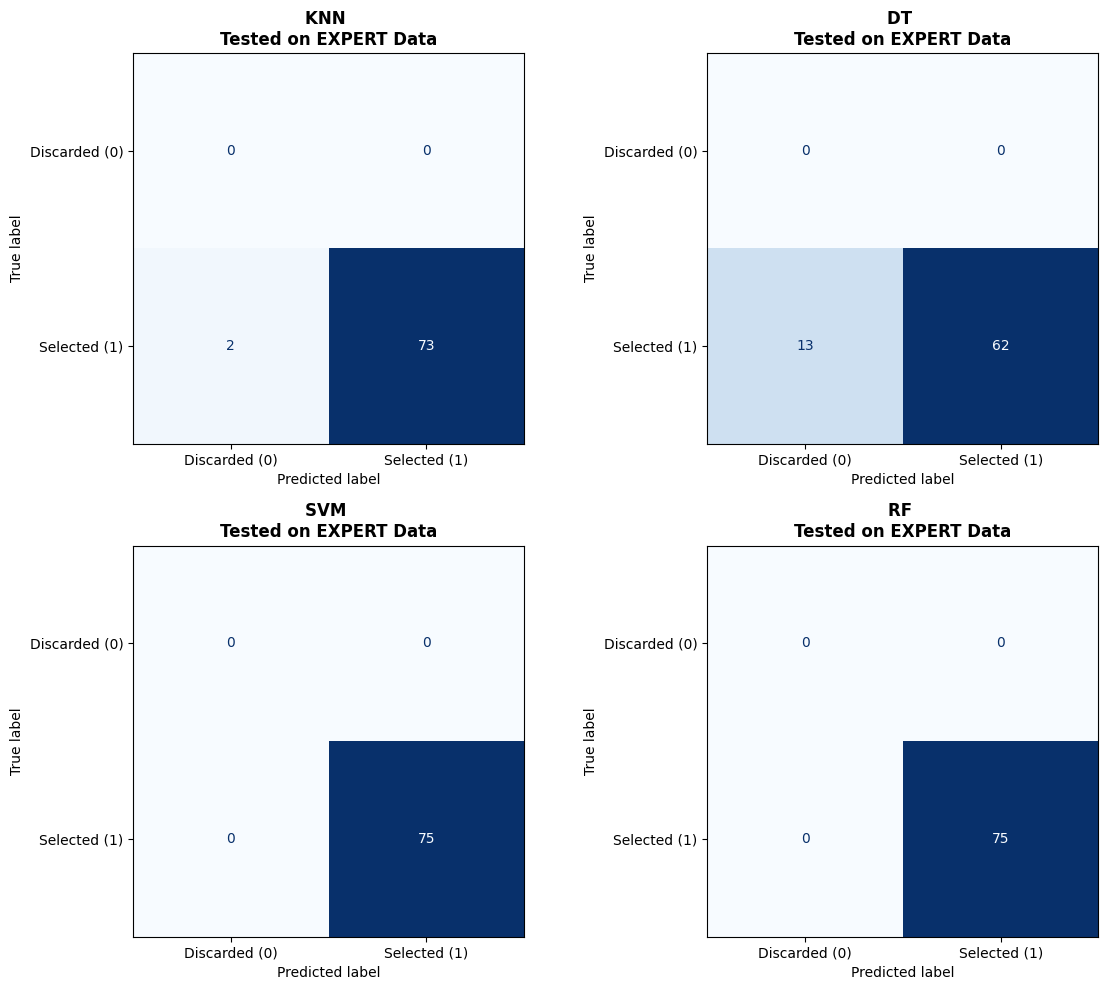

In [ ]:
C_range = np.logspace(-2, 2, 5)
gamma_range = np.logspace(-3, -1, 3)

models_config = {
    'KNN': {
        'model': Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())]),
        'params': {'clf__n_neighbors': list(range(1, 10)), 'clf__p': [1, 2]}
    },
    'DT': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': list(range(1, 10)) + [None], 'criterion': ['gini', 'entropy']}
    },
    'SVM': {
        'model': Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=False, random_state=42))]),
        'params': [
            {'clf__kernel': ['rbf'], 'clf__C': C_range, 'clf__gamma': gamma_range},
            {'clf__kernel': ['linear'], 'clf__C': C_range}
        ]
    },
    'RF': {
        'model': RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [10, 50, 100, 200]}
    }
}

inner_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

results_log = []
confusion_data = {}

for name, config in models_config.items():
    print(f"🔄 {name} ...")

    # --- Stage 1: Find best parameters on Player_created Level Data (X_train) ---
    clf = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=inner_cv,
        scoring='accuracy',
        n_jobs=-1
    )

    # Train using ONLY Player_created Level Data!
    clf.fit(X_train, y_train)

    best_player_score = clf.best_score_
    best_params = clf.best_params_

    # --- Stage 2: Final test on Expert Data (X_test) ---
    # Predict unseen expert levels using the model trained on player patterns
    y_pred = clf.predict(X_test)
    expert_test_acc = accuracy_score(y_test, y_pred)

    confusion_data[name] = (y_test, y_pred)

    print(f"  >> Player CV Score (Inner): {best_player_score:.4f}")
    print(f"  >> Expert Final Test Score (Outer): {expert_test_acc:.4f}")
    print(f"  >> Best Hyperparameters: {best_params}")
    print("-" * 50)

    results_log.append({
        'Model': name,
        'Player_Train_Acc': f"{best_player_score:.4f}",
        'Expert_Test_Acc': f"{expert_test_acc:.4f}",
        'Best_Params': str(best_params)
    })

# ==========================================
# 3. Print
# ==========================================
results_df = pd.DataFrame(results_log)
print("\n=== Cross-Domain Performance Summary ===")
print(results_df.to_string(index=False))

# Plot Confusion Matrices (2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
labels_display = ['Discarded (0)', 'Selected (1)']

for i, (name, (y_t, y_p)) in enumerate(confusion_data.items()):

    cm = confusion_matrix(y_t, y_p, labels=[0, 1])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_display)
    disp.plot(ax=axes[i], cmap='Blues', values_format='d', colorbar=False)
    axes[i].set_title(f'{name} \nTested on EXPERT Data', fontsize=12, fontweight='bold')
    axes[i].grid(False)

plt.tight_layout()
plt.show()


with Best Parameters

In [ ]:
models = {
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=9, p=1))
    ]),

    'DT': DecisionTreeClassifier(
        criterion='gini',
        max_depth=2,
        random_state=42
    ),

    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='linear', C=100.0, probability=True, random_state=42))
    ]),

    'RF': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}


cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
scoring_metrics = ['accuracy', 'roc_auc', 'f1_macro']

final_results = []

for name, model in models.items():
    print(f"  {name} ...")
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring_metrics, n_jobs=-1)


    final_results.append({
        'Model': name,
        'Accuracy': f"{cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}",
        'ROC_AUC': f"{cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}",
        'F1_Score': f"{cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}"
    })

# ==========================================
# 3. Print Final Performance Comparison Table
# ==========================================
results_df = pd.DataFrame(final_results)
print("\n" + "="*60)
print("FINAL MODELS PERFORMANCE (with Cross-Domain Best Hyperparameters)")
print("="*60)
print(results_df.to_string(index=False))

  KNN ...
  DT ...
  SVM ...
  RF ...

FINAL MODELS PERFORMANCE (with Cross-Domain Best Hyperparameters)
Model        Accuracy         ROC_AUC        F1_Score
  KNN 0.8229 ± 0.0505 0.9027 ± 0.0455 0.8172 ± 0.0506
   DT 0.8201 ± 0.0467 0.8796 ± 0.0402 0.7998 ± 0.0506
  SVM 0.8347 ± 0.0473 0.9091 ± 0.0384 0.8209 ± 0.0521
   RF 0.8302 ± 0.0356 0.9281 ± 0.0257 0.8133 ± 0.0371


### Nested CV

#### Models Performance (with Best Hyperparameters)

| Model | Accuracy | ROC_AUC | F1_Score |
|-------|----------|---------|----------|
| KNN | 0.8229 ± 0.0505 | 0.9027 ± 0.0455 | 0.8172 ± 0.0506 |
| DT  | 0.8201 ± 0.0467 | 0.8796 ± 0.0402 | 0.7998 ± 0.0506 |
| SVM | 0.8311 ± 0.0546 | 0.9048 ± 0.0414 | 0.8149 ± 0.0585 |
| RF  | 0.8302 ± 0.0372 | 0.9300 ± 0.0260 | 0.8137 ± 0.0384 |

### Train: Player  
### Test: Expert

#### Models Performance (with Best Hyperparameters)

| Model | Accuracy | ROC_AUC | F1_Score |
|-------|----------|---------|----------|
| KNN | 0.8229 ± 0.0505 | 0.9027 ± 0.0455 | 0.8172 ± 0.0506 |
| DT  | 0.8201 ± 0.0467 | 0.8796 ± 0.0402 | 0.7998 ± 0.0506 |
| SVM | 0.8347 ± 0.0473 | 0.9091 ± 0.0384 | 0.8209 ± 0.0521 |
| RF  | 0.8302 ± 0.0356 | 0.9281 ± 0.0257 | 0.8133 ± 0.0371 |


### Observations:
- RF got the most robust performance with the lowest error margin (± 0.0356) across all tests. Its results show the same in both rounds.

- SVM got the highest overall accuracy in both rounds, especially in the second round (83.47%)

- This results show better perforamnce than nested cross-validation results.

In [ ]:


cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

# Added 'neg_root_mean_squared_error' to the metrics
scoring_metrics = ['accuracy', 'roc_auc', 'f1_macro', 'neg_root_mean_squared_error']
outcome_sd = np.std(y, ddof=0)
final_results = []

for name, model in models.items():
    print(f"   ⏳ Evaluating {name} ...")
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring_metrics, n_jobs=-1)

    # Note: sklearn returns negative RMSE, so we multiply by -1 to get the actual RMSE
    mean_rmse = -cv_results['test_neg_root_mean_squared_error'].mean()
    std_rmse = cv_results['test_neg_root_mean_squared_error'].std()

    final_results.append({
        'Model': name,
        'Accuracy': f"{cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}",
        'ROC_AUC': f"{cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}",
        'F1_Score': f"{cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}",
        'RMSE': f"{mean_rmse:.4f} ± {std_rmse:.4f}",
        'Outcome_SD': f"{outcome_sd:.4f}"
    })

# ==========================================
# 4. Print Final Performance Comparison Table
# ==========================================
results_df = pd.DataFrame(final_results)
print("\n" + "="*75)
print("FINAL MODELS PERFORMANCE (Including RMSE)")
print("="*75)
print(results_df.to_string(index=False))

   ⏳ Evaluating KNN ...
   ⏳ Evaluating DT ...
   ⏳ Evaluating SVM ...
   ⏳ Evaluating RF ...

FINAL MODELS PERFORMANCE (Including RMSE)
Model        Accuracy         ROC_AUC        F1_Score            RMSE Outcome_SD
  KNN 0.8229 ± 0.0505 0.9027 ± 0.0455 0.8172 ± 0.0506 0.4164 ± 0.0607     0.4760
   DT 0.8201 ± 0.0467 0.8796 ± 0.0402 0.7998 ± 0.0506 0.4205 ± 0.0559     0.4760
  SVM 0.8347 ± 0.0473 0.9091 ± 0.0384 0.8209 ± 0.0521 0.4028 ± 0.0558     0.4760
   RF 0.8302 ± 0.0356 0.9281 ± 0.0257 0.8133 ± 0.0371 0.4098 ± 0.0429     0.4760


Important Features of ML models

In [ ]:
from sklearn.inspection import permutation_importance

feature_names = X.columns

print("==================================================")
print("FEATURE IMPORTANCE")
print("==================================================")

for name, model in models.items():
    print(f"{name}...")

    model.fit(X, y)

    result = permutation_importance(model, X, y, n_repeats=10, random_state=42, n_jobs=-1)

    importances = result.importances_mean
    indices = np.argsort(importances)[::-1]

    print(f"  --- Top 10 Features for {name} ---")
    for i in range(min(10, len(feature_names))):
        feature = feature_names[indices[i]]
        score = importances[indices[i]]
        print(f"  {i+1}. {feature:<20} (Score: {score:.4f})")


FEATURE IMPORTANCE
KNN...
  --- Top 10 Features for KNN ---
  1. UGC_ONE_WAY_PLATFORM_count (Score: 0.0274)
  2. UGC_SLIMY_count      (Score: 0.0082)
  3. UGC_CHARACTER_LEMMING_1_value (Score: 0.0027)
  4. UGC_GOAL_WALK_count  (Score: 0.0023)
  5. Player_created       (Score: 0.0018)
  6. UGC_ICE_BLOCK_1_count (Score: 0.0014)
  7. UGC_EDITABLE_RECTANGLE_ICE_1_value (Score: -0.0018)
  8. UGC_PLATFORM_BUBBLE_count (Score: -0.0018)
  9. UGC_EDITABLE_RECTANGLE_LAVA_1_value (Score: -0.0023)
  10. UGC_BALLOON_count    (Score: -0.0027)
DT...
  --- Top 10 Features for DT ---
  1. UGC_ONE_WAY_PLATFORM_count (Score: 0.1740)
  2. UGC_GOAL_WALK_count  (Score: 0.1105)
  3. Player_created       (Score: 0.0000)
  4. UGC_SLIMY_count      (Score: 0.0000)
  5. UGC_ICE_BLOCK_1_count (Score: 0.0000)
  6. UGC_EDITABLE_RECTANGLE_LAVA_1_value (Score: 0.0000)
  7. UGC_EDITABLE_RECTANGLE_ICE_1_value (Score: 0.0000)
  8. UGC_BALLOON_count    (Score: 0.0000)
  9. UGC_CHARACTER_LEMMING_1_value (Score: 0.0000)
  1

###Most Important Features - Observations：

- UGC_ONE_WAY_PLATFORM

- UGC_GOAL_WALK

- UGC_PLATFORM_BUBBLE

- UGC_BALLOON_count

- UGC_SLIMY_count

Decision Tree Plot

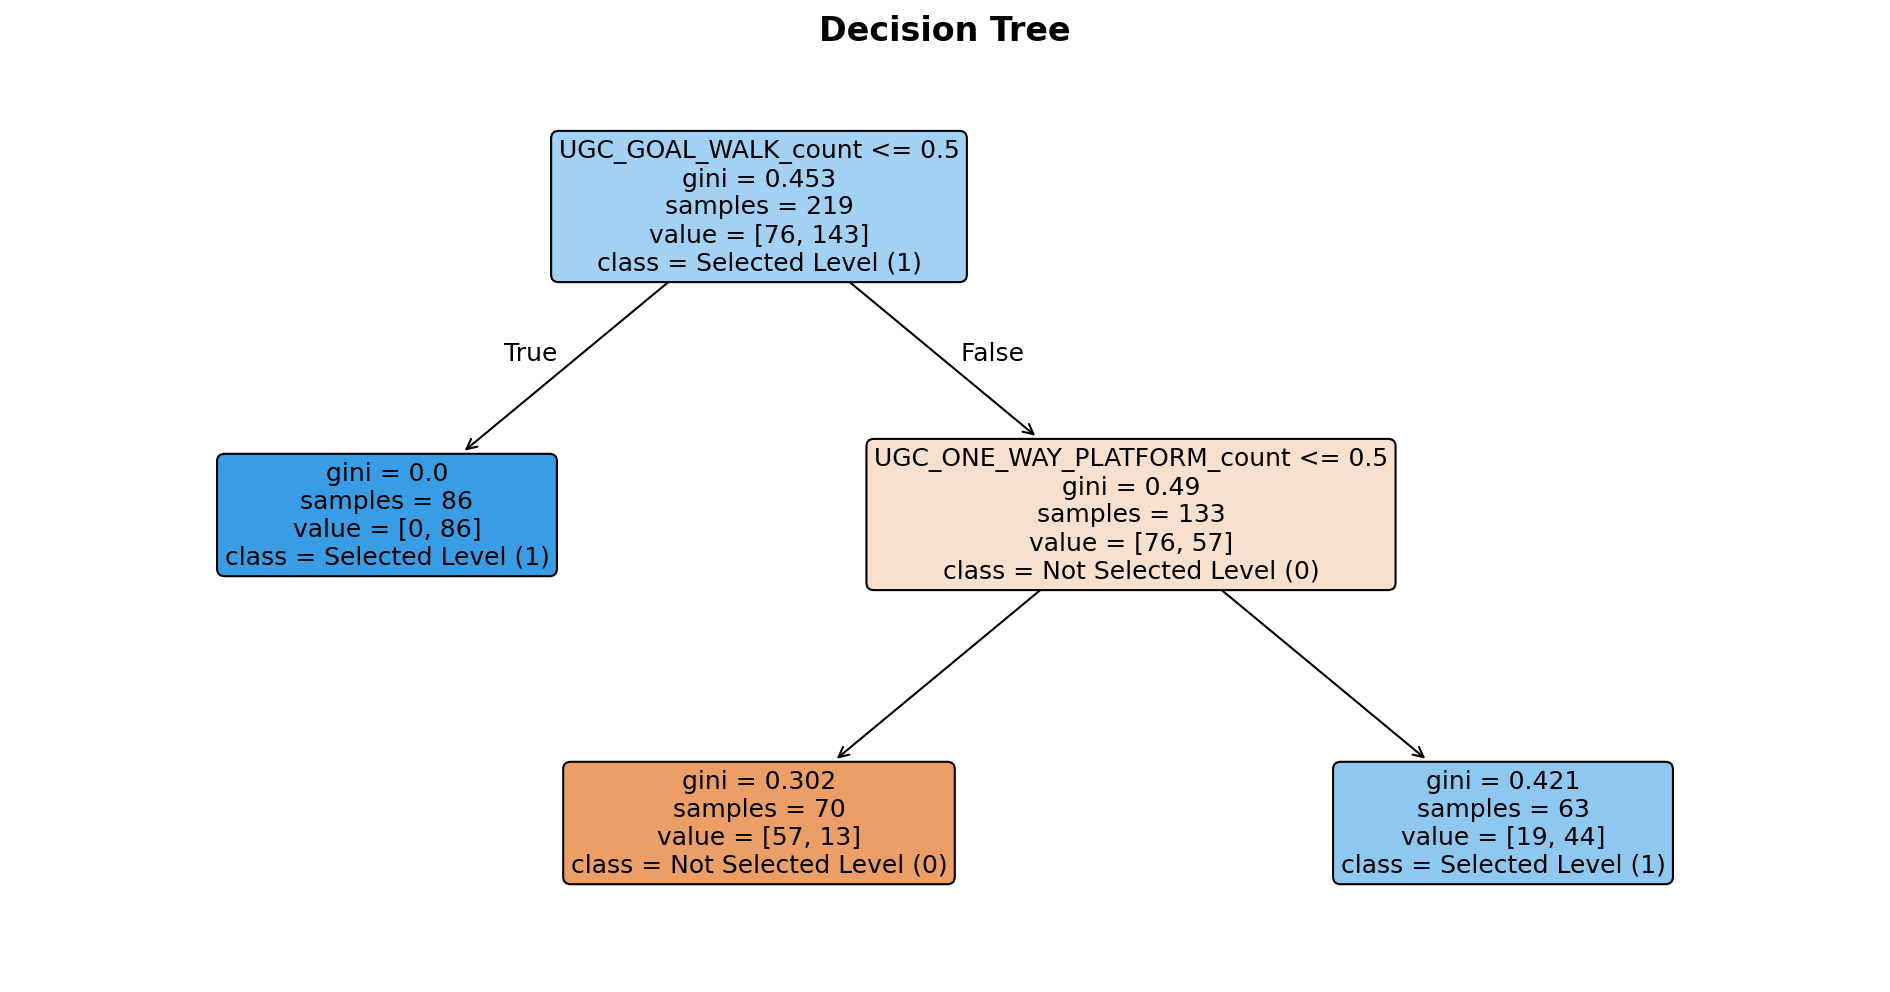

In [ ]:
from sklearn.tree import plot_tree

dt_model = models['DT']
dt_model.fit(X, y)

plt.figure(figsize=(16, 8), dpi=150)
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['Not Selected Level (0)', 'Selected Level (1)'],
          filled=True,
          rounded=True,
          fontsize=12)

plt.title("Decision Tree", fontsize=16, fontweight='bold')
plt.show()

**Train: expert-created levels**

**Test: player-created levels**

In [ ]:
train_df = df[df['Player_created'] == 0]

test_df = df[df['Player_created'] == 1]

In [ ]:
X_train = train_df[selected_features]
y_train = train_df[target_variable]

X_test = test_df[selected_features]
y_test = test_df[target_variable]

In [ ]:
C_range = np.logspace(-2, 2, 5)
gamma_range = np.logspace(-3, -1, 3)

models_config = {
    'KNN': {
        'model': Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())]),
        'params': {'clf__n_neighbors': list(range(1, 10)), 'clf__p': [1, 2]}
    },
    'DT': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': list(range(1, 10)) + [None], 'criterion': ['gini', 'entropy']}
    },
    'SVM': {
        'model': Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=False, random_state=42))]),
        'params': [
            {'clf__kernel': ['rbf'], 'clf__C': C_range, 'clf__gamma': gamma_range},
            {'clf__kernel': ['linear'], 'clf__C': C_range}
        ]
    },
    'RF': {
        'model': RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [10, 50, 100, 200]}
    }
}

inner_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

results_log = []
confusion_data = {}

print("Class distribution in y_train (expert-created levels):")
print(y_train.value_counts())
print(f"Number of unique classes in y_train: {len(y_train.unique())}")
print("-" * 50)

for name, config in models_config.items():
    print(f"🔄 {name} ...")


    if len(y_train.unique()) < 2:
        print(f"  Skipping {name}: y_train for expert-created levels has only one class, cannot perform classification.")
        results_log.append({
            'Model': name,
            'Player_Train_Acc': 'N/A',
            'Expert_Test_Acc': 'N/A',
            'Best_Params': 'N/A'
        })

        confusion_data[name] = ([], [])
        print("-" * 50)
        continue

    clf = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=inner_cv,
        scoring='accuracy',
        n_jobs=-1
    )


    clf.fit(X_train, y_train)

    best_player_score = clf.best_score_
    best_params = clf.best_params_

    y_pred = clf.predict(X_test)
    expert_test_acc = accuracy_score(y_test, y_pred)

    confusion_data[name] = (y_test, y_pred)

    print(f"  >> Expert CV Score (Inner): {best_player_score:.4f}")
    print(f"  >> Player Final Test Score (Outer): {expert_test_acc:.4f}")
    print(f"  >> Best Hyperparameters: {best_params}")
    print("-" * 50)

    results_log.append({
        'Model': name,
        'Player_Train_Acc': f"{best_player_score:.4f}",
        'Expert_Test_Acc': f"{expert_test_acc:.4f}",
        'Best_Params': str(best_params)
    })

# ==========================================
# 3. Print
# ==========================================
results_df = pd.DataFrame(results_log)
print("\n=== Cross-Domain Performance Summary ===")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
labels_display = ['Discarded (0)', 'Selected (1)']

filtered_confusion_data = {k: v for k, v in confusion_data.items() if len(v[0]) > 0}

for i, (name, (y_t, y_p)) in enumerate(filtered_confusion_data.items()):

    cm = confusion_matrix(y_t, y_p, labels=[0, 1])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_display)
    disp.plot(ax=axes[i], cmap='Blues', values_format='d', colorbar=False)
    axes[i].set_title(f'{name} \nTested on PLAYER Data', fontsize=12, fontweight='bold')
    axes[i].grid(False)

for j in range(len(filtered_confusion_data), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Class distribution in y_train (expert-created levels):
Selected
1    75
Name: count, dtype: int64
Number of unique classes in y_train: 1
--------------------------------------------------
🔄 KNN ...
  Skipping KNN: y_train for expert-created levels has only one class, cannot perform classification.
--------------------------------------------------
🔄 DT ...
  Skipping DT: y_train for expert-created levels has only one class, cannot perform classification.
--------------------------------------------------
🔄 SVM ...
  Skipping SVM: y_train for expert-created levels has only one class, cannot perform classification.
--------------------------------------------------
🔄 RF ...
  Skipping RF: y_train for expert-created levels has only one class, cannot perform classification.
--------------------------------------------------

=== Cross-Domain Performance Summary ===
Model Player_Train_Acc Expert_Test_Acc Best_Params
  KNN              N/A             N/A         N/A
   DT              N/A  

<Figure size 1200x1000 with 0 Axes>